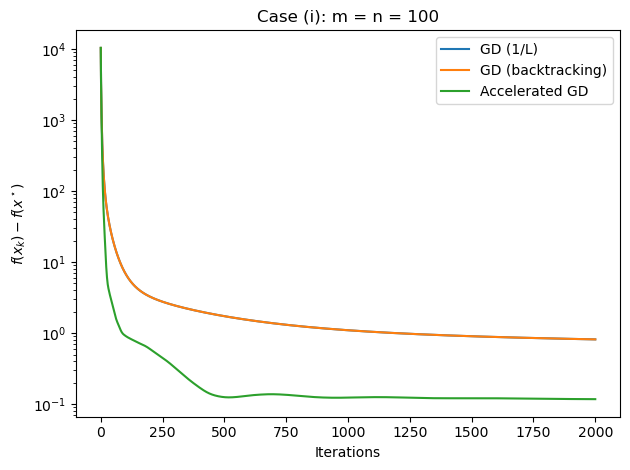

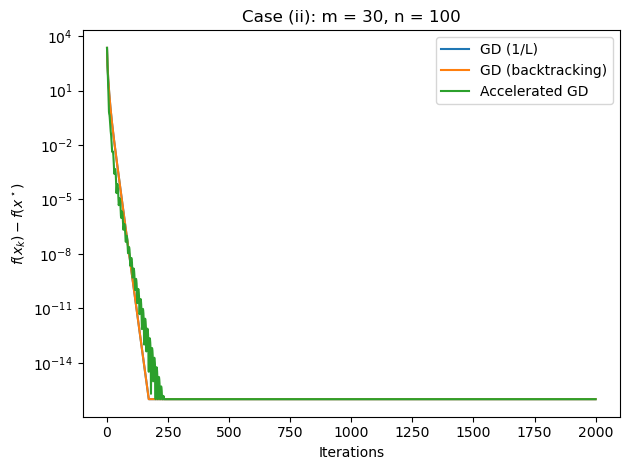

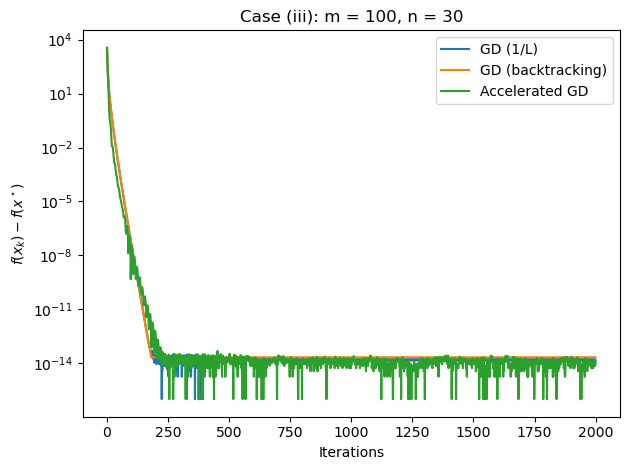

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(m, n, sigma=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(m) * sigma
    b = A @ w_true + noise
    return A, b

def f_val(A, b, x):
    r = A @ x - b
    return float(r @ r) 

def grad(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)  

def L_lipschitz(A):
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2 * (smax**2)  

def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    vals = []
    for _ in range(iters):
        vals.append(f_val(A, b, x))
        x -= t * grad(A, b, x)
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None:
        t0 = 1.0 / L_lipschitz(A)
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_val(A, b, x)
        vals.append(fx)
        g = grad(A, b, x)
        t = t0
        g2 = float(g @ g)
        while True:
            x_new = x - t * g
            if f_val(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    y = x0.copy()
    vals = []
    for k in range(1, iters + 1):
        vals.append(f_val(A, b, x))
        g = grad(A, b, y)
        x_next = y - t * g
        theta = (k - 1) / (k + 2)  
        y = x_next + theta * (x_next - x)
        x = x_next
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def solve_star(A, b):
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    return x_star

def run_and_plot(m, n, iters=2000, seed=42, title=""):
    A, b = make_data(m, n, seed=seed)
    x0 = np.zeros(n)
    x_star = solve_star(A, b)
    f_star = f_val(A, b, x_star)

    _, v1 = gd_constant(A, b, x0, iters)
    _, v2 = gd_backtracking(A, b, x0, iters)
    _, v3 = accel_gd(A, b, x0, iters)

    plt.figure()
    for label, vals in {
        "GD (1/L)": v1,
        "GD (backtracking)": v2,
        "Accelerated GD": v3
    }.items():
        gap = np.maximum(vals - f_star, 1e-16) 
        plt.semilogy(gap, label=label)
    plt.xlabel("Iterations")
    plt.ylabel(r"$f(x_k) - f(x^\star)$")
    plt.title(title or f"m={m}, n={n}")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_and_plot(100, 100, iters=2000, title="Case (i): m = n = 100")
    run_and_plot(30, 100, iters=2000, title="Case (ii): m = 30, n = 100")
    run_and_plot(100, 30, iters=2000, title="Case (iii): m = 100, n = 30")

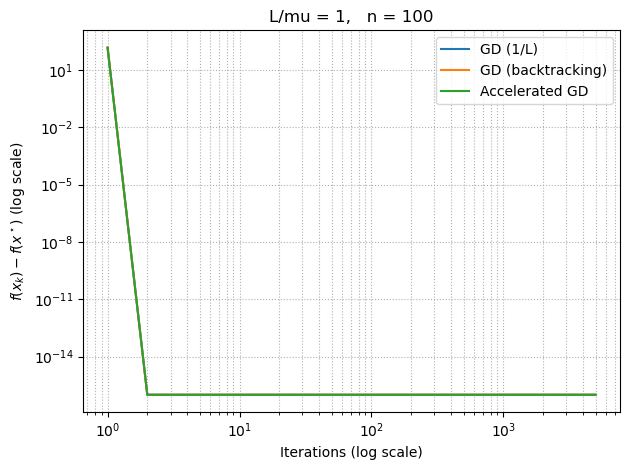

[Check] target L/mu=1, actual L/mu=1.00


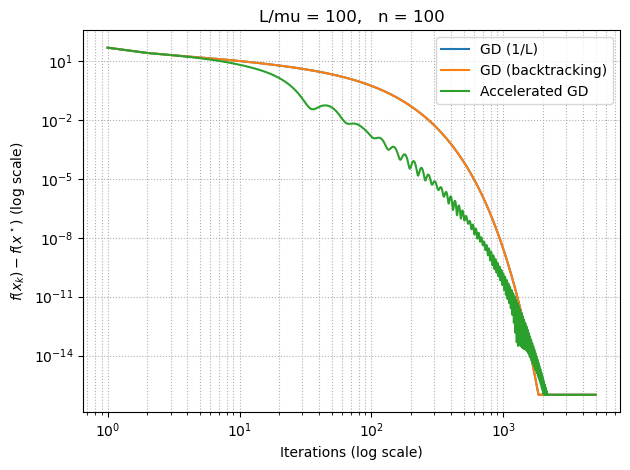

[Check] target L/mu=100, actual L/mu=100.00


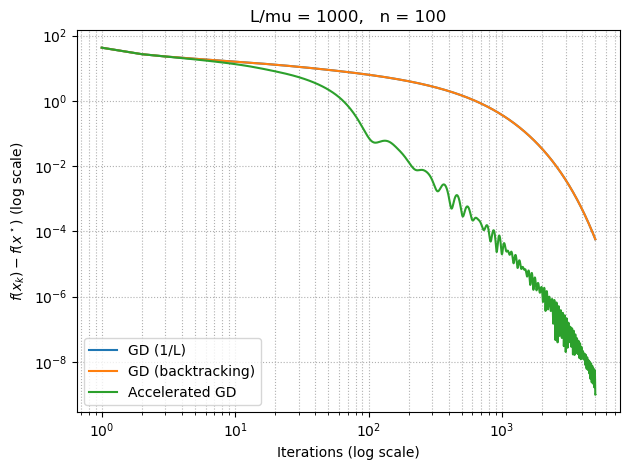

[Check] target L/mu=1000, actual L/mu=1000.00


In [2]:

def f_val(A, b, x):
    r = A @ x - b
    return float(r @ r) 

def grad(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)  

def L_lipschitz(A):
    # L = 2 * sigma_max(A)**2
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax ** 2)

def mu_strong(A):
    # μ = 2 * sigma_min(A)**2
    s = np.linalg.svd(A, compute_uv=False)
    smin = s[-1]
    return 2.0 * (smin ** 2)

def solve_star(A, b):
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    return x_star

# set up 3 gd
def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    vals = []
    for _ in range(iters):
        vals.append(f_val(A, b, x))
        x -= t * grad(A, b, x)
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None:
        t0 = 1.0 / L_lipschitz(A)
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_val(A, b, x)
        vals.append(fx)
        g = grad(A, b, x)
        t = t0
        g2 = float(g @ g)
        # Armijo
        while True:
            x_new = x - t * g
            if f_val(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy()
    y = x0.copy()
    vals = []
    for k in range(1, iters + 1):
        vals.append(f_val(A, b, x))
        g = grad(A, b, y)
        x_next = y - t * g
        theta = (k - 1.0) / (k + 2.0)
        y = x_next + theta * (x_next - x)
        x = x_next
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

# generate A
def random_orthogonal(n, rng):
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    return Q

def make_A_with_L_over_mu(n=100, L_over_mu=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    sigma_max = 1.0
    sigma_min = 1.0 / np.sqrt(L_over_mu) 
    if n == 1:
        s = np.array([sigma_max])
    else:
        s = np.geomspace(sigma_max, sigma_min, num=n) 
    U = random_orthogonal(n, rng)
    V = random_orthogonal(n, rng)
    S = np.diag(s)
    A = U @ S @ V.T
    return A

def make_instance(n=100, L_over_mu=1.0, sigma_noise=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = make_A_with_L_over_mu(n=n, L_over_mu=L_over_mu, rng=rng)
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(n) * sigma_noise
    b = A @ w_true + noise
    return A, b

def run_case(L_over_mu, n=100, iters=5000, seed=42, show=True):
    A, b = make_instance(n=n, L_over_mu=L_over_mu, seed=seed)
    x0 = np.zeros(n)
    x_star = solve_star(A, b)
    f_star = f_val(A, b, x_star)

    _, v1 = gd_constant(A, b, x0, iters)
    _, v2 = gd_backtracking(A, b, x0, iters)
    _, v3 = accel_gd(A, b, x0, iters)

    gaps = {
        "GD (1/L)": v1,
        "GD (backtracking)": v2,
        "Accelerated GD": v3
    }

    steps = np.arange(1, len(v1) + 1)
    eps = 1e-16

    plt.figure()
    for lab, vals in gaps.items():
        gap = np.maximum(vals - f_star, eps)
        plt.loglog(steps, gap, label=lab)
    plt.xlabel("Iterations (log scale)")
    plt.ylabel(r"$f(x_k) - f(x^\star)$ (log scale)")
    plt.title(f"L/mu = {L_over_mu:.0f},   n = {n}")
    plt.legend()
    plt.grid(True, which="both", ls=":")
    plt.tight_layout()
    if show:
        plt.show()

    L = L_lipschitz(A)
    mu = mu_strong(A)
    print(f"[Check] target L/mu={L_over_mu:.0f}, actual L/mu={L/mu:.2f}")

if __name__ == "__main__":
    for kappa in [1, 100, 1000]:
        run_case(L_over_mu=kappa, n=100, iters=5000, seed=42)

[Instance] target L/mu=10, actual L/mu=10.0000, L=2.0000, mu=0.2000


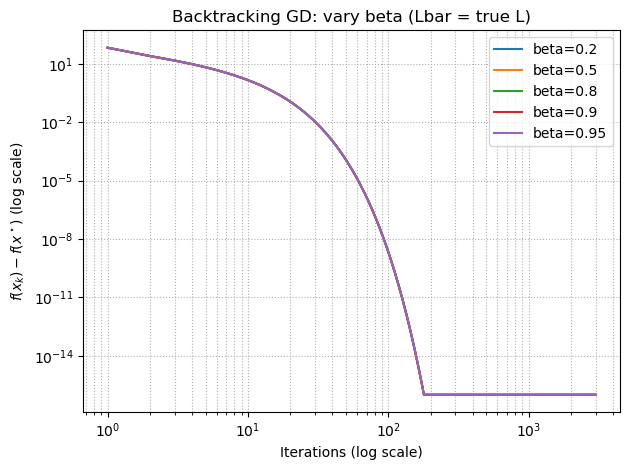

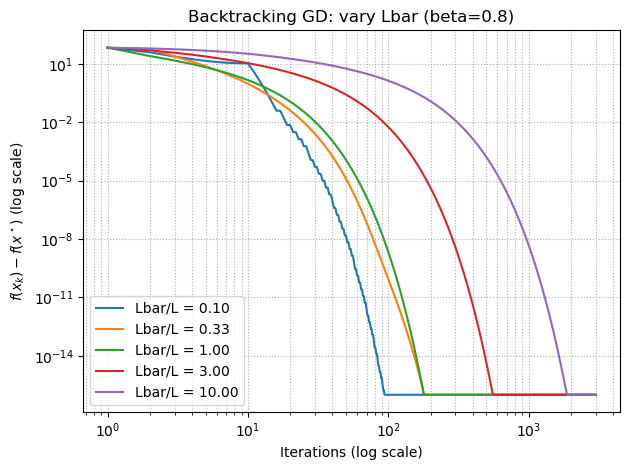

In [3]:

def f_val(A, b, x):
    # ||Ax-b||^2
    r = A @ x - b
    return float(r @ r)  

def grad(A, b, x):
    # ∇f = 2 A^T (Ax-b)
    r = A @ x - b
    return 2.0 * (A.T @ r)  

def L_lipschitz(A):
    # L = 2 * sigma_max(A)^2
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax**2)

def mu_strong(A):
    # μ = 2 * sigma_min(A)^2
    s = np.linalg.svd(A, compute_uv=False)
    smin = s[-1]
    return 2.0 * (smin**2)

def solve_star(A, b):
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    return x_star

def bls_gd(A, b, x0, iters, Lbar=None, beta=0.8, c=1e-4):
    if Lbar is None:
        Lbar = L_lipschitz(A)
    t0 = 1.0 / Lbar
    x = x0.copy()
    vals = []
    for _ in range(iters):
        fx = f_val(A, b, x)
        vals.append(fx)
        g = grad(A, b, x)
        g2 = float(g @ g)
        t = t0
        while True:
            x_new = x - t * g
            if f_val(A, b, x_new) <= fx - c * t * g2:
                break
            t *= beta
        x = x_new
    vals.append(f_val(A, b, x))
    return x, np.array(vals)

def random_orthogonal(n, rng):
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

def make_A_with_L_over_mu(n=100, L_over_mu=10.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    sigma_max = 1.0
    sigma_min = 1.0 / np.sqrt(L_over_mu)
    s = np.geomspace(sigma_max, sigma_min, num=n)  

    U = random_orthogonal(n, rng)
    V = random_orthogonal(n, rng)
    S = np.diag(s)
    A = U @ S @ V.T
    return A

def make_instance(n=100, kappa=10.0, sigma_noise=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = make_A_with_L_over_mu(n=n, L_over_mu=kappa, rng=rng)
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(n) * sigma_noise
    b = A @ w_true + noise
    return A, b

def plot_loglog_curves(curves, f_star, title):
    eps = 1e-16
    plt.figure()
    for label, vals in curves:
        steps = np.arange(1, len(vals) + 1)  # 1..T
        gap = np.maximum(vals - f_star, eps)
        plt.loglog(steps, gap, label=label)
    plt.xlabel("Iterations (log scale)")
    plt.ylabel(r"$f(x_k) - f(x^\star)$ (log scale)")
    plt.title(title)
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

def main():
    n = 100
    kappa = 10.0              
    iters = 3000
    seed = 42

    A, b = make_instance(n=n, kappa=kappa, seed=seed)
    true_L = L_lipschitz(A)
    true_mu = mu_strong(A)
    print(f"[Instance] target L/mu=10, actual L/mu={true_L/true_mu:.4f}, L={true_L:.4f}, mu={true_mu:.4f}")

    x0 = np.zeros(n)
    x_star = solve_star(A, b)
    f_star = f_val(A, b, x_star)

    betas = [0.2, 0.5, 0.8, 0.9, 0.95]
    curves = []
    for beta in betas:
        _, v = bls_gd(A, b, x0, iters, Lbar=true_L, beta=beta, c=1e-4)
        curves.append((f"beta={beta}", v))
    plot_loglog_curves(curves, f_star, title="Backtracking GD: vary beta (Lbar = true L)")

    beta_fixed = 0.8
    Lbars = [true_L/10, true_L/3, true_L, 3*true_L, 10*true_L]  
    curves = []
    for Lbar in Lbars:
        _, v = bls_gd(A, b, x0, iters, Lbar=Lbar, beta=beta_fixed, c=1e-4)
        curves.append((f"Lbar/L = {Lbar/true_L:.2f}", v))
    plot_loglog_curves(curves, f_star, title=f"Backtracking GD: vary Lbar (beta={beta_fixed})")

if __name__ == "__main__":
    main()